
TEAM MEMBERS:
1. Yacoba Oduro-Yeboah
2. Caleb Fianku Quao

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

# Import preprocessing libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score, classification_report

In [ ]:
# Load Dataset from github repository
heart_df = pd.read_csv("/content/framingham.csv")
heart_df.head()


,Unnamed: 0,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,male,39,4.0,No,0.0,No,No,No,No,195.0,106.0,70.0,26.97,80.0,77.0,0
1,1,female,46,2.0,No,0.0,No,No,No,No,250.0,121.0,81.0,28.73,95.0,76.0,0
2,2,male,48,1.0,Yes,20.0,No,No,No,No,245.0,127.5,80.0,25.34,75.0,70.0,0
3,3,female,61,3.0,Yes,30.0,No,No,Yes,No,225.0,150.0,95.0,28.58,65.0,103.0,1
4,4,female,46,3.0,Yes,23.0,No,No,No,No,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
#Number of rows
print(heart_df.shape[0])
#Number of columns
print(heart_df.shape[1])

4238
17


In [ ]:
# Checking information about the dataset using info
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       4238 non-null   int64  
 1   sex              4238 non-null   object 
 2   age              4238 non-null   int64  
 3   education        4133 non-null   float64
 4   currentSmoker    4238 non-null   object 
 5   cigsPerDay       4209 non-null   float64
 6   BPMeds           4185 non-null   object 
 7   prevalentStroke  4238 non-null   object 
 8   prevalentHyp     4238 non-null   object 
 9   diabetes         4238 non-null   object 
 10  totChol          4188 non-null   float64
 11  sysBP            4238 non-null   float64
 12  diaBP            4238 non-null   float64
 13  BMI              4219 non-null   float64
 14  heartRate        4237 non-null   float64
 15  glucose          3850 non-null   float64
 16  TenYearCHD       4238 non-null   int64  
dtypes: float64(8),

In [ ]:
heart_df.duplicated().sum()

0

In [ ]:
# Checking missing values/null values count for each column
heart_df.isnull().sum()

Unnamed: 0           0
sex                  0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [ ]:
# Dataset Describe (all columns included)
heart_df.describe(include= 'all')

,Unnamed: 0,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238,4238.000000,4133.000000,4238,4209.000000,4185,4238,4238,4238,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
unique,NaN,2,NaN,NaN,2,NaN,2,2,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,female,NaN,NaN,No,NaN,No,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,2419,NaN,NaN,2144,NaN,4061,4213,2922,4129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2118.500000,NaN,49.584946,1.978950,NaN,9.003089,NaN,NaN,NaN,NaN,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,1223.549549,NaN,8.572160,1.019791,NaN,11.920094,NaN,NaN,NaN,NaN,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,NaN,32.000000,1.000000,NaN,0.000000,NaN,NaN,NaN,NaN,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,1059.250000,NaN,42.000000,1.000000,NaN,0.000000,NaN,NaN,NaN,NaN,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,2118.500000,NaN,49.000000,2.000000,NaN,0.000000,NaN,NaN,NaN,NaN,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,3177.750000,NaN,56.000000,3.000000,NaN,20.000000,NaN,NaN,NaN,NaN,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000


In [ ]:
# Duplicate the dataset to clean it from the original dataset
h_df = heart_df.copy()
h_df.head()

,Unnamed: 0,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,male,39,4.0,No,0.0,No,No,No,No,195.0,106.0,70.0,26.97,80.0,77.0,0
1,1,female,46,2.0,No,0.0,No,No,No,No,250.0,121.0,81.0,28.73,95.0,76.0,0
2,2,male,48,1.0,Yes,20.0,No,No,No,No,245.0,127.5,80.0,25.34,75.0,70.0,0
3,3,female,61,3.0,Yes,30.0,No,No,Yes,No,225.0,150.0,95.0,28.58,65.0,103.0,1
4,4,female,46,3.0,Yes,23.0,No,No,No,No,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
# prompt: drop all missing values in each columns
#h_df = h_df.dropna()

h_df.heartRate = h_df.heartRate.fillna(0)
most_cigs = h_df.cigsPerDay.mode()[0]
most_tot = h_df.totChol.mode()[0]
most_bmi = h_df.BMI.mode()[0]
most_glu = h_df.glucose.mode()[0]
h_df.cigsPerDay = h_df.cigsPerDay.fillna(most_cigs)
h_df.BMI = h_df.BMI.fillna(most_bmi)
h_df.BPMeds = h_df.BPMeds.fillna(0)
h_df.totChol = h_df.totChol.fillna(most_tot)
h_df.glucose = h_df.glucose.fillna(most_glu)
h_df.head()


,Unnamed: 0,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,male,39,4.0,No,0.0,No,No,No,No,195.0,106.0,70.0,26.97,80.0,77.0,0
1,1,female,46,2.0,No,0.0,No,No,No,No,250.0,121.0,81.0,28.73,95.0,76.0,0
2,2,male,48,1.0,Yes,20.0,No,No,No,No,245.0,127.5,80.0,25.34,75.0,70.0,0
3,3,female,61,3.0,Yes,30.0,No,No,Yes,No,225.0,150.0,95.0,28.58,65.0,103.0,1
4,4,female,46,3.0,Yes,23.0,No,No,No,No,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
h_df.isna().sum()

Unnamed: 0           0
sex                  0
age                  0
education          105
currentSmoker        0
cigsPerDay           0
BPMeds               0
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol              0
sysBP                0
diaBP                0
BMI                  0
heartRate            0
glucose              0
TenYearCHD           0
dtype: int64

In [ ]:
print(h_df.shape[0])
print(h_df.shape[1])

4238
17


In [ ]:
h_df.drop(labels = ['Unnamed: 0','education'], axis = 1, inplace = True)

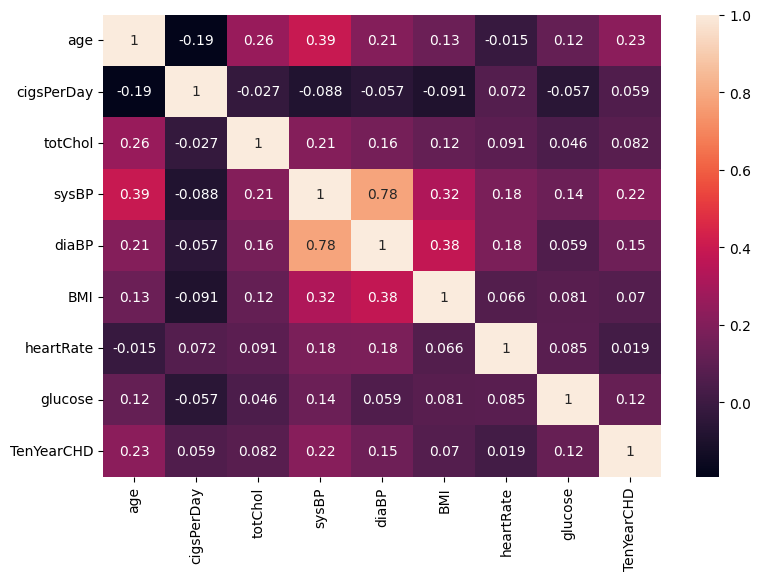

In [ ]:
# Check the correlation between numerical features using a heatmap
# Select only numerical columns for correlation calculation
numerical_df = h_df.select_dtypes(include=['float', 'int'])
corr = numerical_df.corr()
plt.figure(figsize=(9,6))
sns.heatmap(corr, annot=True)
plt.show()


In [ ]:
h_df.dtypes

sex                 object
age                  int64
currentSmoker       object
cigsPerDay         float64
BPMeds              object
prevalentStroke     object
prevalentHyp        object
diabetes            object
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

# **Age and Total Cholesterol**
Older individuals might have higher cholesterol levels due to age-related metabolic changes. This relationship is important because high cholesterol is a significant risk factor for heart disease. By understanding how cholesterol levels change with age, we can identify age groups that might need more aggressive monitoring or intervention.

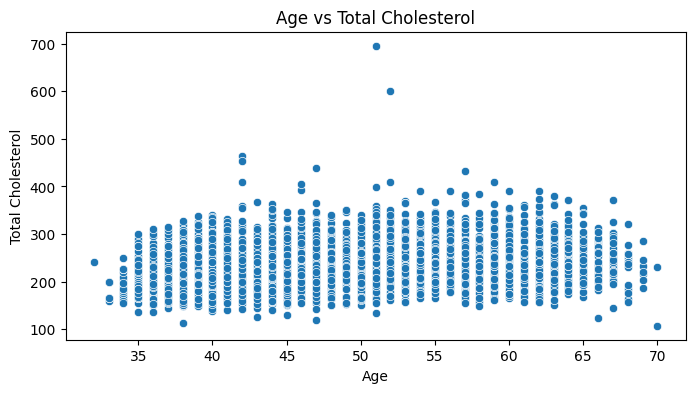

Correlation between age and total cholesterol: 0.26


In [ ]:
# Scatter plot of age vs total cholesterol
plt.figure(figsize=(8, 4))
sns.scatterplot(x='age', y='totChol', data=h_df)
plt.title('Age vs Total Cholesterol')
plt.xlabel('Age')
plt.ylabel('Total Cholesterol')
plt.show()

# Statistical summary
age_chol_corr = h_df['age'].corr(h_df['totChol'])
print(f'Correlation between age and total cholesterol: {age_chol_corr:.2f}')


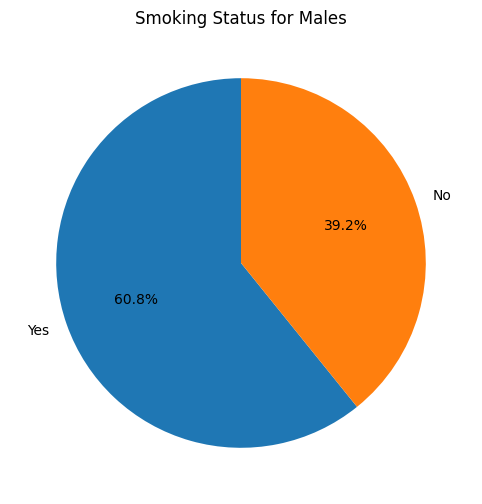

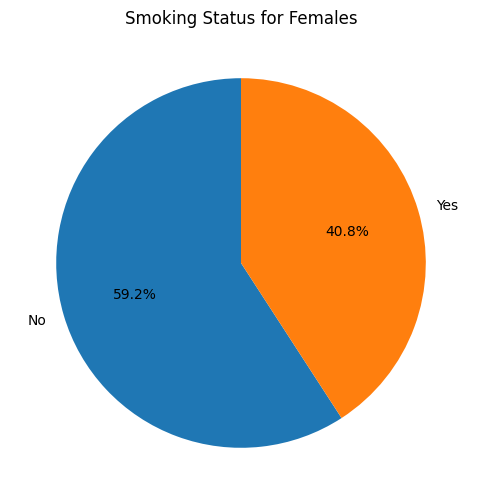

In [ ]:
# Plot pie chart for males
male_smoking_status = h_df[h_df['sex'] == 'male']['currentSmoker'].value_counts()
male_smoking_status.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(8, 6), colors=['#1f77b4', '#ff7f0e'])
plt.title('Smoking Status for Males')
plt.ylabel('')
plt.show()

# Plot pie chart for females
female_smoking_status = h_df[h_df['sex'] == 'female']['currentSmoker'].value_counts()
female_smoking_status.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(8, 6), colors=['#1f77b4', '#ff7f0e'])
plt.title('Smoking Status for Females')
plt.ylabel('')
plt.show()




# **TenYearCHD by Age**

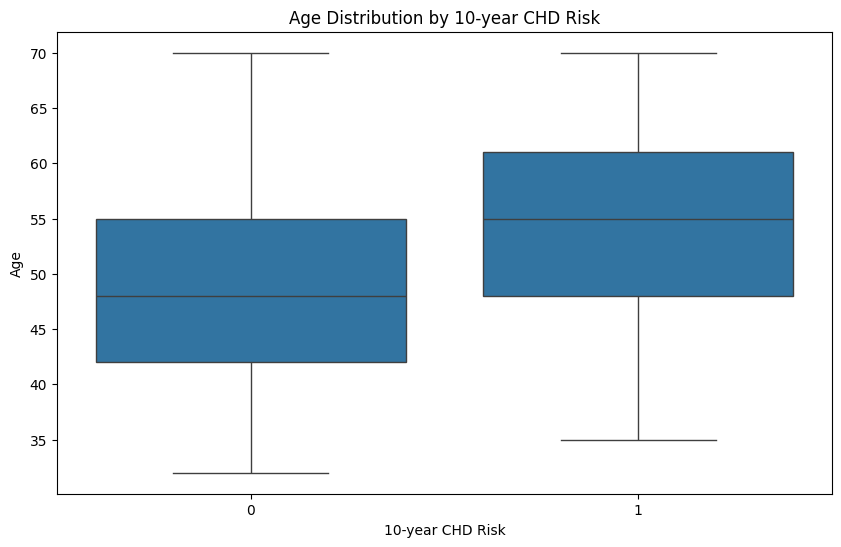

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='TenYearCHD', y='age', data=h_df)
plt.title('Age Distribution by 10-year CHD Risk')
plt.xlabel('10-year CHD Risk')
plt.ylabel('Age')
plt.show()



# **TenYearCHD by Sex**

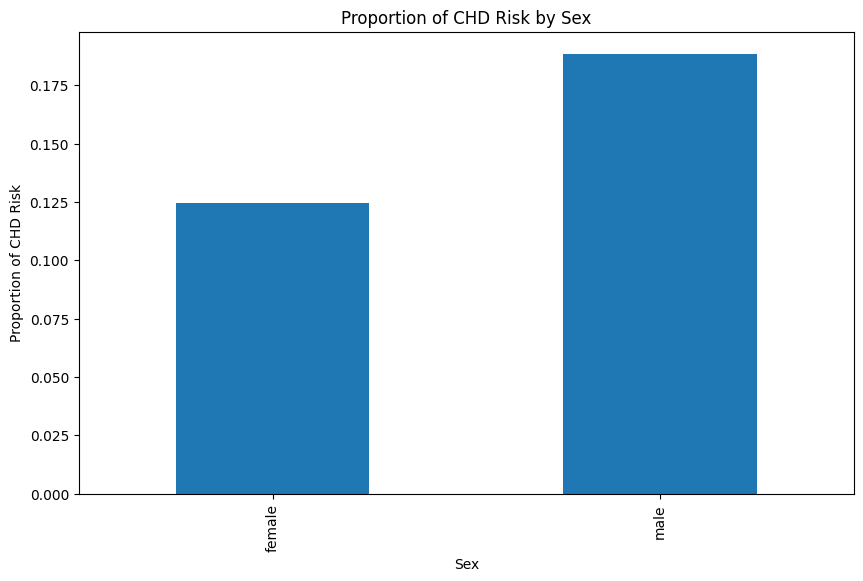

In [ ]:
plt.figure(figsize=(10, 6))
h_df.groupby('sex')['TenYearCHD'].mean().plot(kind='bar')
plt.title('Proportion of CHD Risk by Sex')
plt.xlabel('Sex')
plt.ylabel('Proportion of CHD Risk')
plt.show()


# **TenYearCHD by Blood Pressure**

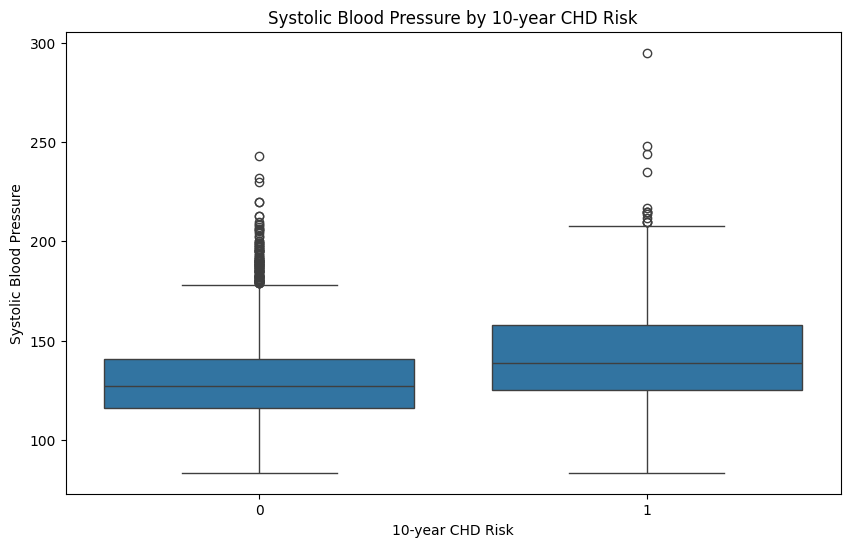

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='TenYearCHD', y='sysBP', data=h_df)
plt.title('Systolic Blood Pressure by 10-year CHD Risk')
plt.xlabel('10-year CHD Risk')
plt.ylabel('Systolic Blood Pressure')
plt.show()



# **TenYearCHD by Smoking Status**

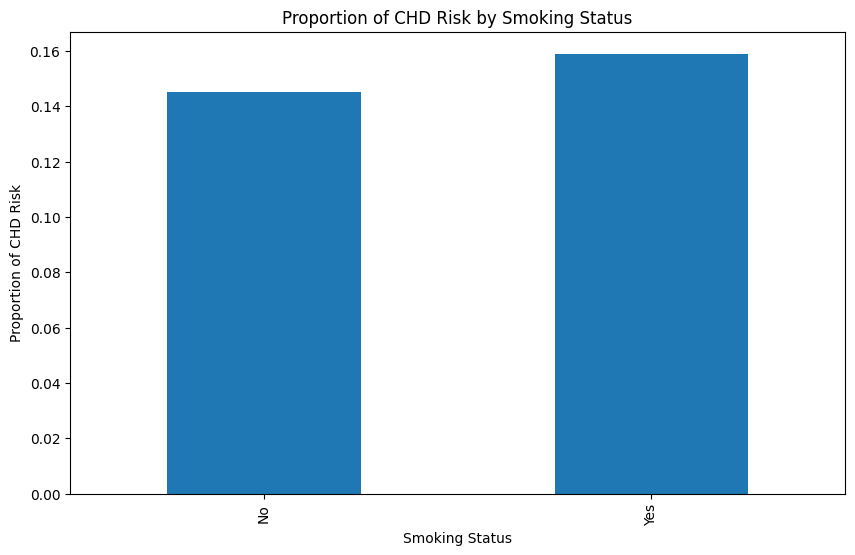

In [ ]:
plt.figure(figsize=(10, 6))
h_df.groupby('currentSmoker')['TenYearCHD'].mean().plot(kind='bar')
plt.title('Proportion of CHD Risk by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Proportion of CHD Risk')
plt.show()


# **Cholesterol and Glucose Levels**

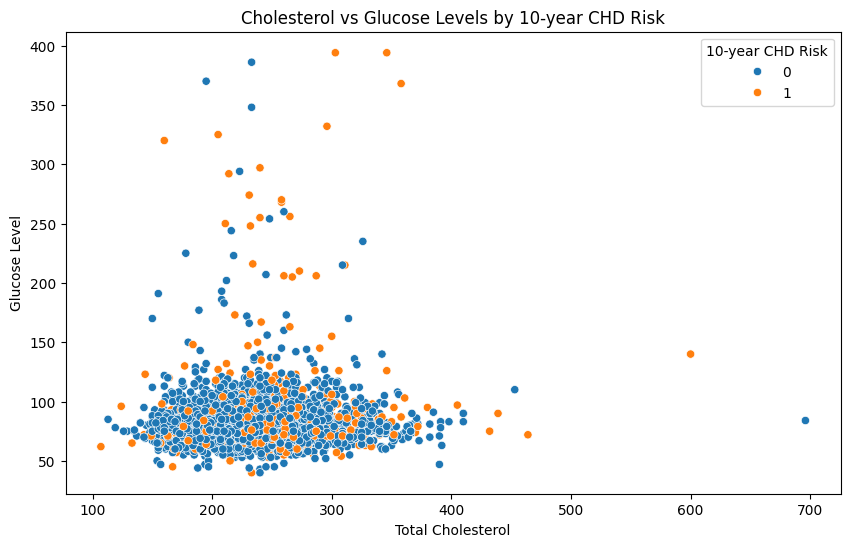

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='totChol', y='glucose', hue='TenYearCHD', data=h_df)
plt.title('Cholesterol vs Glucose Levels by 10-year CHD Risk')
plt.xlabel('Total Cholesterol')
plt.ylabel('Glucose Level')
plt.legend(title='10-year CHD Risk')
plt.show()


In [ ]:
#Let know the type of data the columns are presented in
categorical_cols = [col_name for col_name in h_df.columns if h_df[col_name].dtype == "object"]
quantitative_cols = [col_name for col_name in h_df.columns if h_df[col_name].dtype in ['int64', 'float64']]

print("Categorical columns:", categorical_cols)
print("Quantitative columns:", quantitative_cols)


Categorical columns: ['sex', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']
Quantitative columns: ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


In [ ]:
target = h_df['TenYearCHD']
input_feats = h_df.drop(labels = ['TenYearCHD'], axis=1)

In [ ]:
cat_cols_input = input_feats.select_dtypes(include='object').columns.tolist()
num_cols_input =  input_feats.select_dtypes(include=np.number).columns.tolist()

In [ ]:
# SPLITTING THE DATASET INTO TRAINING AND TEST SETS
X_train, X_test, y_train, y_test = train_test_split(input_feats, target, test_size=0.2, random_state=0)

In [ ]:
#ENCODING THE CATGEGORICAL VARIABLES
from sklearn.feature_extraction import DictVectorizer


In [ ]:
encoder0 = OneHotEncoder().fit(X_train.loc[:, ['sex']])
encoded_cols_0 = list(encoder0.get_feature_names_out(['sex']))
X_train[encoded_cols_0] = encoder0.transform(X_train.loc[:, ['sex']]).toarray()
encoded_X_train = X_train.drop(labels=['sex'], axis=1)

columns_to_convert = ['currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']
encoded_X_train[columns_to_convert] = encoded_X_train[columns_to_convert].replace({'Yes': True, 'No': False}).astype(int)

In [ ]:

scaler = StandardScaler().fit(encoded_X_train[num_cols_input])
encoded_X_train[num_cols_input] = scaler.transform(encoded_X_train[num_cols_input])

In [ ]:

model = LogisticRegression()

model.fit(encoded_X_train, y_train)





LogisticRegression()

In [ ]:
model.predict_proba(encoded_X_train)

array([[0.56654453, 0.43345547],
       [0.78109652, 0.21890348],
       [0.9164788 , 0.0835212 ],
       ...,
       [0.93710573, 0.06289427],
       [0.79684688, 0.20315312],
       [0.91586748, 0.08413252]])

In [ ]:
train_pred = model.predict(encoded_X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"Accuracy score of model on the training set: {train_accuracy*100:.2f}%")


Accuracy score of model on the training set: 85.87%


In [ ]:
#TESTING PERFORMANCE OF MODEL ON TEST SET


In [ ]:

def process_test(test_set):
   test_set[encoded_cols_0] = encoder0.transform(test_set.loc[:, ['sex']]).toarray()
   encoded_X_test = X_test.drop(labels=['sex'], axis=1)

   columns_to_convert = ['currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']
   encoded_X_test[columns_to_convert] = encoded_X_test[columns_to_convert].replace({'Yes': True, 'No': False}).astype(int)

   encoded_X_test[num_cols_input] = scaler.transform(encoded_X_test[num_cols_input])

   return encoded_X_test

In [ ]:
processed_test_set = process_test(X_test)
test_preds = model.predict(processed_test_set)
test_accuracy = accuracy_score(y_test, test_preds)
print(f"Accuracy score of model on the test set: {test_accuracy*100:.2f}%")

Accuracy score of model on the test set: 84.67%


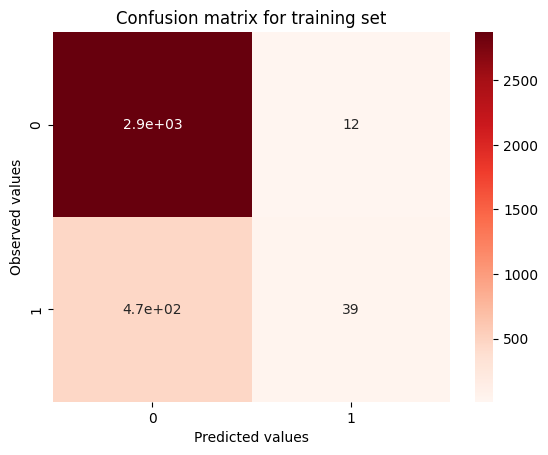

In [ ]:
def plot_confusion_matrix(y_act, y_pred, title='', cmap='Reds'):
    cm = confusion_matrix(y_act, y_pred)
    sns.heatmap(cm, annot=True, cmap=cmap)
    plt.title(title)
    plt.xlabel('Predicted values')
    plt.ylabel('Observed values')

plot_confusion_matrix(y_train, train_pred, title='Confusion matrix for training set')

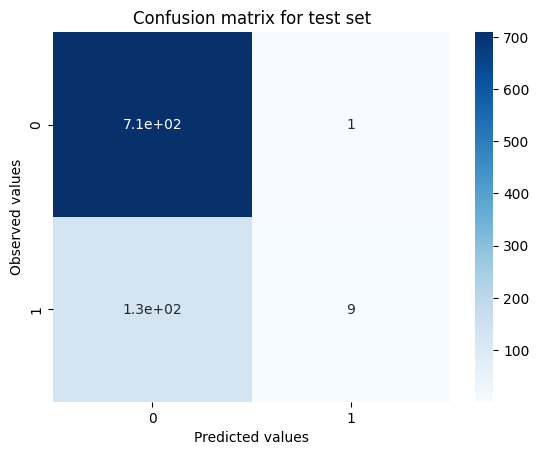

In [ ]:
plot_confusion_matrix(y_test, test_preds, title='Confusion matrix for test set', cmap='Blues')

In [ ]:
test_precision = precision_score(y_test, test_preds)
print(f"Precision score of model on the test set: {test_precision*100:.2f}%")

Precision score of model on the test set: 90.00%


In [ ]:
test_recall = recall_score(y_test, test_preds)
print(f"Recall score of model on the test set: {test_recall*100:.2f}%")

Recall score of model on the test set: 6.52%


In [ ]:
test_f1 = f1_score(y_test, test_preds)
print(f"F1 score of model on the test set: {test_f1*100:.2f}%")

F1 score of model on the test set: 12.16%


In [ ]:
test_roc_auc = roc_auc_score(y_test, test_preds)
print(f"ROC-AUC score of model on the test set: {test_roc_auc*100:.2f}%")

ROC-AUC score of model on the test set: 53.19%


In [ ]:
levels = pd.factorize(h_df['sex'])
print(classification_report(y_test,test_preds, target_names=["Male", "Female"]))

              precision    recall  f1-score   support

        Male       0.85      1.00      0.92       710
      Female       0.90      0.07      0.12       138

    accuracy                           0.85       848
   macro avg       0.87      0.53      0.52       848
weighted avg       0.85      0.85      0.79       848

